In [ ]:
#homework 11!

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
#PLOTTING AN ASTRONOMICAL IMAGE

In [20]:
data = np.loadtxt("astro_image.csv")

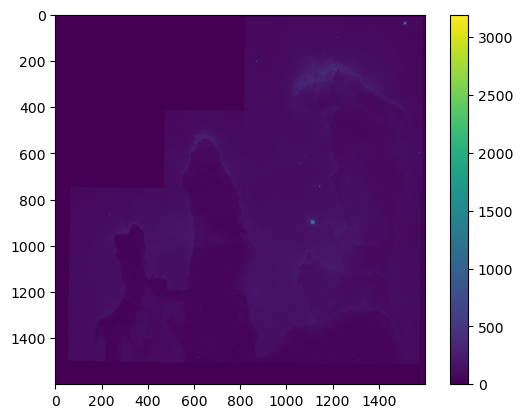

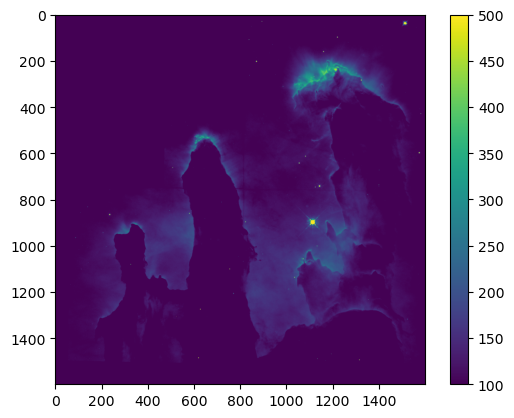

In [30]:
#1
plt.figure()
plt.imshow(data) #plotting original
plt.colorbar()

plt.figure()
plt.imshow(data, vmin= 100, vmax=500 ) #plotting with vmin and vmax
plt.colorbar()

Text(0.5, 1.0, 'The top of this pillar')

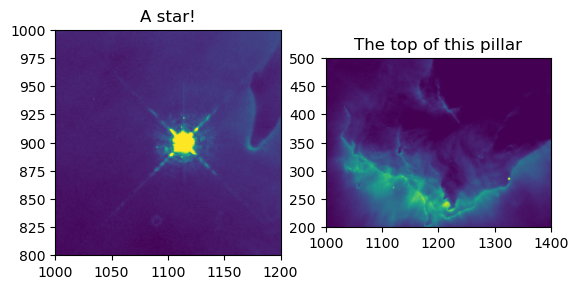

In [35]:
#2
fig,ax= plt.subplots(1,2)

ax[0].imshow(data, vmin=100, vmax = 500)
ax[0].set_xlim(1000,1200)
ax[0].set_ylim(800,1000)
ax[0].set_title("A star!")

ax[1].imshow(data, vmin=100, vmax = 500)
ax[1].set_xlim(1000,1400)
ax[1].set_ylim(200,500)
ax[1].set_title("The top of this pillar")

In [37]:
#PANDAS AND RAMEN

In [38]:
df = pd.read_csv("ramen-ratings.csv")

1. What are the column names in this dataset?

column names: Review #, Brand, Variety, Style, Country, Stars, Top Ten

In [47]:
df.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

2. What is the ramen style of the 27th entry?

the style of the 27th entry is Pack style ramen. 

In [48]:
df.loc[df["Review #"] == 27]

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
2553,27,Nissin,Demae Ramen Curry Flavor,Pack,Japan,4,NaN


3. How many different ramen brands are there?

In [52]:
print(f"There are {len(df["Brand"].unique())} unique ramen brands")

There are 355 unique ramen brands


4. Sort the dataset by brand names.

In [55]:
df.sort_values(by = "Brand")

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN
...,...,...,...,...,...,...,...
823,1757,iMee,Instant Noodles Beef Flavour,Pack,Netherlands,3.25,NaN
662,1918,iMee,Instant Noodles chicken Flavour,Pack,Netherlands,3.5,NaN
797,1783,iMee,Instant Noodles Creamy Tom Yum Shrimp Flavour,Pack,Netherlands,4.5,NaN
2135,445,iNoodle,Taiwan Style Chow Mein,Pack,Taiwan,2.25,NaN


5. How many ramen brands are made in the USA?

In [67]:
filtered_df = df[df["Country"] == "USA"]
print(f"{len(filtered_df["Brand"].unique())} ramen brands are made in the USA")

49 ramen brands are made in the USA


6. How many ramen brands in the USA make pack-style ramen?

In [70]:
filtered_df_again = filtered_df[filtered_df["Style"] == "Pack"]
print(f"{len(filtered_df_again["Brand"].unique())} ramen brands in the USA make pack-style ramen")

27 ramen brands in the USA make pack-style ramen


7. Challenge: Which ramen brands have been in the top ten? (Top tem column entry is not
NaN)

In [79]:
top_ten_df = df.dropna()


print("The following ramen brands have been in the top ten:")
for brand in top_ten_df["Brand"].unique():
    print(brand)

The following ramen brands have been in the top ten:
MAMA
Prima Taste
Prima
Tseng Noodles
Wugudaochang
A-Sha Dry Noodle
MyKuali
CarJEN
Maruchan
Mamee
Mama
Sapporo Ichiban
Nongshim
Samyang Foods
Paldo
Indomie
Koka
Mi Sedaap
Nissin
Myojo
Doll


In [ ]:
#LINEAR REGRESSION

In [127]:
from astropy.table import Table
from scipy.optimize import curve_fit

In [124]:
from astropy.io import ascii
ascii.get_reader().read('global_CCl4_MM.dat') #just to see what the data looks like, bc it was reading it weirdly

CCl4ottoyr,CCl4ottomon,CCl4ottoNHm,CCl4ottoNHsd,CCl4ottoSHm,CCl4ottoSHsd,CCl4ottoGLm,CCl4ottoGLsd
int64,int64,float64,float64,float64,float64,float64,float64
1996,1,nan,nan,nan,nan,nan,nan
1996,2,nan,nan,nan,nan,nan,nan
1996,3,nan,nan,nan,nan,nan,nan
1996,4,105.318,0.197,102.969,0.238,104.144,0.155
1996,5,105.032,0.193,102.754,0.287,103.893,0.174
1996,6,105.327,0.277,103.086,0.273,104.207,0.191
1996,7,105.25,0.171,103.021,0.233,104.136,0.147
1996,8,104.855,0.239,102.817,0.213,103.836,0.161
1996,9,104.909,0.248,102.813,0.441,103.861,0.254


In [104]:
#1
table = Table.read("global_CCl4_MM.dat", format='ascii' )



In [114]:
#2
tabledf = table.to_pandas()
df1 = tabledf[["CCl4ottoyr", "CCl4ottoGLm", "CCl4ottoGLsd"]]

In [134]:
df1 = df1.dropna(axis=0)

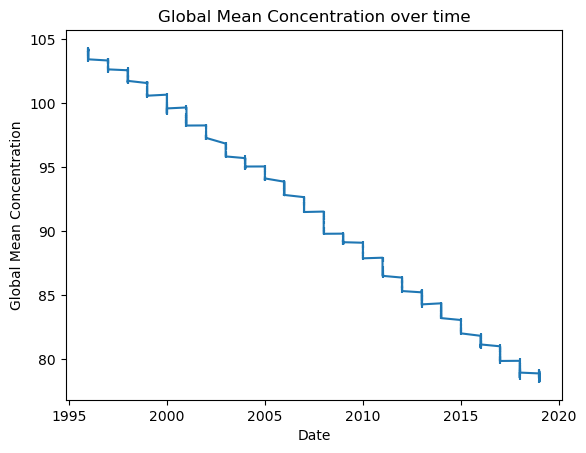

In [135]:
#3
plt.figure()
x = df1["CCl4ottoyr"]
y = df1["CCl4ottoGLm"]
plt.errorbar(x, y, xerr= None, yerr= df1["CCl4ottoGLsd"])
plt.xlabel("Date")
plt.ylabel("Global Mean Concentration")
plt.title("Global Mean Concentration over time")
plt.show()

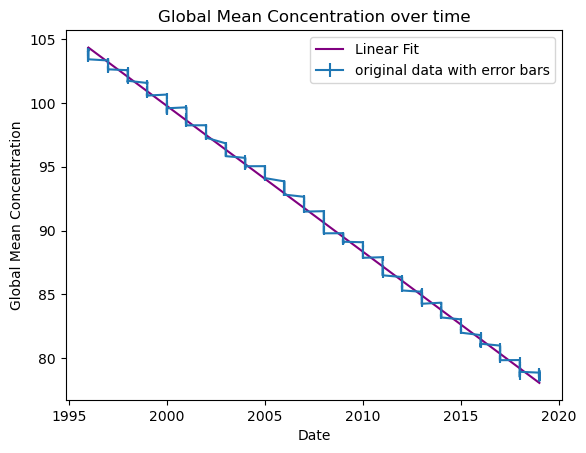

In [145]:
#4
def linear_fit(x, m, b):
    return m*x +b
    
popt, pcov = curve_fit(linear_fit, x, y)

m_fit, b_fit = popt

plt.figure()
x = df1["CCl4ottoyr"]
y = df1["CCl4ottoGLm"]
plt.errorbar(x, y, xerr= None, yerr= df1["CCl4ottoGLsd"], label = "original data with error bars")
plt.plot(x, m_fit*x +b_fit, color = "purple", label = "Linear Fit")
plt.xlabel("Date")
plt.ylabel("Global Mean Concentration")
plt.title("Global Mean Concentration over time")
plt.legend()
plt.show()


In [140]:
#5
error = df1["CCl4ottoGLsd"] #uncertainty

residuals= linear_fit(x, m_fit, b_fit) - y #residuals

chi2 = np.sum(residuals**2/error**2)

dof = len(x) - 1
chi2_squared = chi2/dof

print(f"Reduced chi-squared: {chi2_squared:.2f}")

Reduced chi-squared: 13.31


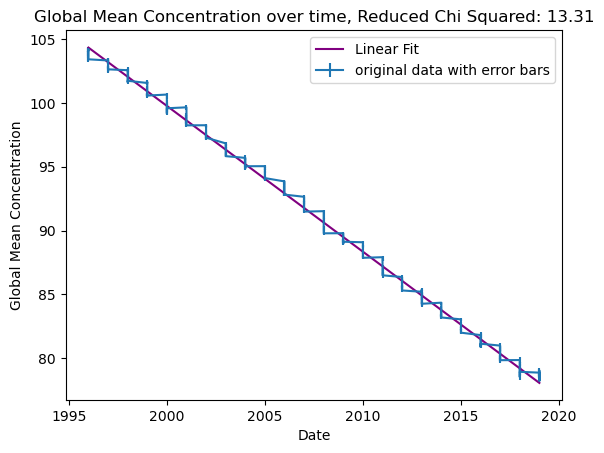

In [146]:
#6
plt.figure()
x = df1["CCl4ottoyr"]
y = df1["CCl4ottoGLm"]
plt.errorbar(x, y, xerr= None, yerr= df1["CCl4ottoGLsd"], label = "original data with error bars")
plt.plot(x, m_fit*x +b_fit, color = "purple", label = "Linear Fit")
plt.xlabel("Date")
plt.ylabel("Global Mean Concentration")
plt.title(f"Global Mean Concentration over time, Reduced Chi Squared: {chi2_squared:.2f}")
plt.legend()
plt.show()

#Since a chi squared value of 1 indicates a good model, I believe my model is fairly good for this data. 